# W03 — CSP Feature Pipeline

## Goal

Transfer the **Common Spatial Patterns (CSP)** idea from EEG motor-imagery analysis to multi-channel robot sensor data.

This notebook:

1. loads the Week 2 higher-frequency robot sensor stream,
2. selects two operational modes (**PATROL vs FAULT** by default),
3. windows the multichannel time series,
4. computes class-conditional covariance matrices from scratch,
5. solves the generalized eigenvalue problem using NumPy,
6. applies CSP spatial filters,
7. extracts log-variance CSP features,
8. compares raw-feature and CSP-feature separability,
9. saves the feature matrices for the Week 3 LDA notebook.

> **Important:** CSP requires multiple time samples within each window. Therefore, this notebook is intended to use the higher-frequency Week 2 sensor stream rather than treating individual 5-minute fleet-telemetry rows as CSP samples.


In [1]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


## 1. Configuration


In [2]:
# -----------------------------
# Configuration
# -----------------------------

DATA_PATH = "../data/robot_sensor_highfreq.csv"

CLASS_A = "PATROL"
CLASS_B = "FAULT"

# High-frequency channels generated in Week 2
CHANNELS = [
    "motor_current",
    "accel_x",
    "accel_y",
    "accel_z",
    "imu_magnitude"
]

FS = 20.0
WINDOW_SEC = 30.0
EXPECTED_SAMPLES_PER_WINDOW = int(FS * WINDOW_SEC)

print("Using data path:", DATA_PATH)
print("Channels:", CHANNELS)
print("Expected samples per window:", EXPECTED_SAMPLES_PER_WINDOW)

Using data path: ../data/robot_sensor_highfreq.csv
Channels: ['motor_current', 'accel_x', 'accel_y', 'accel_z', 'imu_magnitude']
Expected samples per window: 600


## 2. Load Week 2 sensor data


In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (48000, 8)


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0



Columns:
['time', 'mode', 'motor_current', 'accel_x', 'accel_y', 'accel_z', 'imu_magnitude', 'window_id']


In [4]:
required_columns = [
    "time",
    "mode",
    "window_id"
] + CHANNELS

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns found.")

All required columns found.


## 3. Keep the two CSP classes

CSP is fundamentally a **two-class** variance-discrimination method.  
We begin with **PATROL vs FAULT**, as suggested in the Week 3 task description.


In [5]:
binary_df = df[
    df["mode"].isin([CLASS_A, CLASS_B])
].copy()

print("Rows per class:")
print(binary_df["mode"].value_counts())

print("\nWindows per class:")
print(
    binary_df.groupby("mode")["window_id"]
    .nunique()
)

print("\nBinary subset shape:", binary_df.shape)

Rows per class:
mode
PATROL    12000
FAULT     12000
Name: count, dtype: int64

Windows per class:
mode
FAULT     20
PATROL    20
Name: window_id, dtype: int64

Binary subset shape: (24000, 8)


## 4. Construct multichannel CSP windows

The Week 2 high-frequency dataset is already organized into independent
30-second windows using `window_id`.

Therefore, no additional sliding-window segmentation is required.

Each `(mode, window_id)` group is converted from:

`600 time samples × 5 sensor channels`

to:

`5 sensor channels × 600 time samples`

In [6]:
def build_window_tensor(data, channels):
    windows = []
    labels = []
    window_ids = []

    for (mode, window_id), group in data.groupby(
        ["mode", "window_id"],
        sort=False
    ):
        group = group.sort_values("time")
        
        if len(group) != EXPECTED_SAMPLES_PER_WINDOW:
            raise ValueError(
                f"{mode} window {window_id} has {len(group)} samples; "
                f"expected {EXPECTED_SAMPLES_PER_WINDOW}."
        )

        X = group[channels].to_numpy(dtype=float).T

        windows.append(X)
        labels.append(mode)
        window_ids.append(window_id)

    return (
        np.asarray(windows),
        np.asarray(labels),
        np.asarray(window_ids)
    )


X_windows, y, window_ids = build_window_tensor(
    binary_df,
    CHANNELS
)

print("Window tensor shape:", X_windows.shape)
print("Expected format: (n_windows, n_channels, n_time_samples)")

print("\nClass counts:")
print(pd.Series(y).value_counts())

Window tensor shape: (40, 5, 600)
Expected format: (n_windows, n_channels, n_time_samples)

Class counts:
PATROL    20
FAULT     20
Name: count, dtype: int64


## 5. Standardize sensor channels

The robot sensor channels have different physical units and numerical scales.
To prevent a large-scale channel from dominating the covariance structure,
each channel is standardized using its global mean and standard deviation
across all PATROL and FAULT windows.

The same scaling parameters are applied to every 30-second window.


In [7]:
# Combine all time samples from all windows
all_samples = np.transpose(
    X_windows,
    (0, 2, 1)
).reshape(-1, len(CHANNELS))

channel_mean = all_samples.mean(axis=0)
channel_std = all_samples.std(axis=0)

# Avoid division by zero
channel_std[channel_std == 0] = 1.0

X_scaled = (
    X_windows
    - channel_mean[None, :, None]
) / channel_std[None, :, None]

scale_df = pd.DataFrame({
    "channel": CHANNELS,
    "mean": channel_mean,
    "std": channel_std
})

display(scale_df)

print("Scaled tensor shape:", X_scaled.shape)

,channel,mean,std
0,motor_current,3.251257,1.388922
1,accel_x,-0.001240,0.428106
2,accel_y,-0.000192,0.378864
3,accel_z,9.810017,0.343627
4,imu_magnitude,9.826668,0.343386


Scaled tensor shape: (40, 5, 600)


## 6. Sanity checks

Before computing CSP, verify that:

- every window has the same shape,
- both classes have multiple windows,
- no NaN or infinite values are present.


In [8]:
print("Number of windows:", len(X_scaled))
print("Channels per window:", X_scaled.shape[1])
print("Samples per window:", X_scaled.shape[2])

print("\nContains NaN:", np.isnan(X_scaled).any())
print("Contains inf:", np.isinf(X_scaled).any())

counts = pd.Series(y).value_counts()

assert X_scaled.shape[0] == 40, \
    "Expected 40 total windows: 20 PATROL + 20 FAULT."

assert X_scaled.shape[1] == len(CHANNELS), \
    "Unexpected number of channels."

assert X_scaled.shape[2] == EXPECTED_SAMPLES_PER_WINDOW, \
    "Each Week 2 high-frequency window should contain 600 samples."

assert len(counts) == 2
assert counts[CLASS_A] == 20
assert counts[CLASS_B] == 20

assert not np.isnan(X_scaled).any()
assert not np.isinf(X_scaled).any()

print("\nSanity checks passed.")

Number of windows: 40
Channels per window: 5
Samples per window: 600

Contains NaN: False
Contains inf: False

Sanity checks passed.


## 7. Compute normalized covariance matrices

For each window, compute its channel-by-channel covariance matrix and normalize by its trace:

`C = (X X^T) / trace(X X^T)`

Then average normalized covariance matrices within each class to obtain `R1` and `R2`.

This is the direct transfer of the standard EEG CSP first-principles procedure.


In [9]:
def normalized_covariance(X):
    """
    X: shape (n_channels, n_time_samples)
    returns: normalized channel covariance matrix
    """
    X = X - X.mean(axis=1, keepdims=True)
    C = X @ X.T
    tr = np.trace(C)

    if tr <= 0:
        raise ValueError("Encountered a window with zero covariance trace.")

    return C / tr


def mean_class_covariance(X_class):
    covs = np.asarray([normalized_covariance(X) for X in X_class])
    return covs.mean(axis=0)

X_A = X_scaled[y == CLASS_A]
X_B = X_scaled[y == CLASS_B]

R1 = mean_class_covariance(X_A)
R2 = mean_class_covariance(X_B)

print(f"{CLASS_A} covariance shape:", R1.shape)
print(f"{CLASS_B} covariance shape:", R2.shape)

print("\nR1 symmetric:", np.allclose(R1, R1.T))
print("R2 symmetric:", np.allclose(R2, R2.T))


PATROL covariance shape: (5, 5)
FAULT covariance shape: (5, 5)

R1 symmetric: True
R2 symmetric: True


## 8. Solve CSP from scratch

The Week 3 task asks for the generalized eigenvalue problem

`R1 w = λ R2 w`.

NumPy does not directly provide a symmetric generalized-eigenvalue solver, so we form

`pinv(R2) @ R1`

and solve its eigenvectors using `numpy.linalg.eig`.

Large eigenvalues correspond to directions with relatively high variance for Class A.  
Small eigenvalues correspond to directions with relatively high variance for Class B.


In [10]:
def fit_csp(R1, R2, n_pairs=2, eps=1e-10):
    """
    Solve R1 w = lambda R2 w using NumPy only.

    Returns
    -------
    W : spatial filters, shape (n_components, n_channels)
    selected_eigenvalues : eigenvalues corresponding to selected filters
    all_eigenvalues : sorted generalized eigenvalues
    """

    n_channels = R1.shape[0]
    n_pairs = min(n_pairs, n_channels // 2)

    # Small diagonal regularization improves numerical stability.
    R2_reg = R2 + eps * np.eye(n_channels)

    M = np.linalg.pinv(R2_reg) @ R1
    eigvals, eigvecs = np.linalg.eig(M)

    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Select directions from both extremes.
    select = list(range(n_pairs)) + list(range(n_channels - n_pairs, n_channels))

    W = eigvecs[:, select].T

    # Normalize each spatial filter.
    W = W / np.linalg.norm(W, axis=1, keepdims=True)

    return W, eigvals[select], eigvals


N_PAIRS = 2 if len(CHANNELS) >= 4 else 1

W, selected_eigvals, all_eigvals = fit_csp(R1, R2, n_pairs=N_PAIRS)

print("All sorted generalized eigenvalues:")
print(all_eigvals)

print("\nSelected eigenvalues:")
print(selected_eigvals)

print("\nSpatial-filter matrix W shape:", W.shape)


All sorted generalized eigenvalues:
[4.01783091 1.29293798 1.15004673 0.18842306 0.11845991]

Selected eigenvalues:
[4.01783091 1.29293798 0.18842306 0.11845991]

Spatial-filter matrix W shape: (4, 5)


## 9. Visualize CSP spatial-filter weights

These weights should **not** be interpreted as literal EEG scalp maps. Here, each coefficient tells us how strongly a robot sensor channel contributes to a discriminative CSP projection.


,motor_current,accel_x,accel_y,accel_z,imu_magnitude
CSP_1,0.922048,-0.113117,-0.000812,-0.370169,-0.002719
CSP_2,0.734653,0.375086,0.048942,-0.397770,0.398722
CSP_3,-0.069220,0.178324,-0.001520,0.560098,-0.806038
CSP_4,-0.000760,0.001967,-0.000083,-0.708432,0.705776


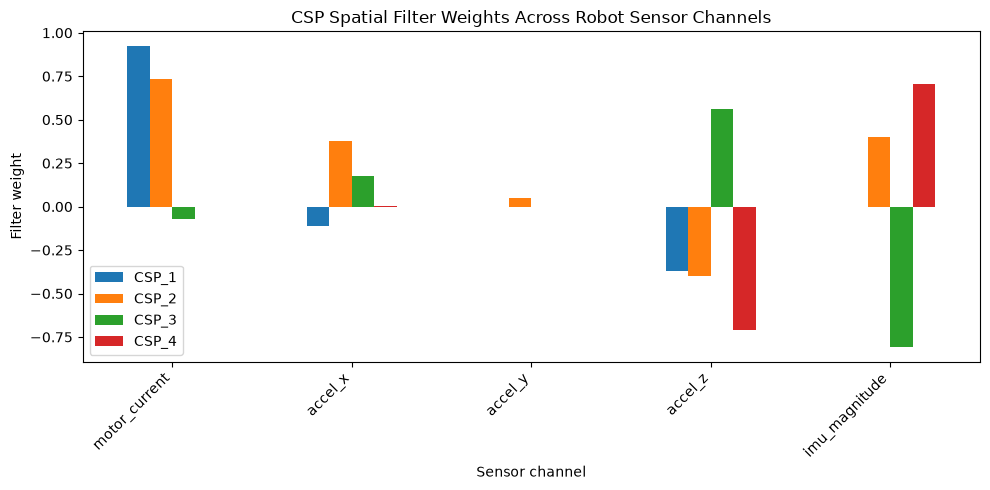

In [11]:
filter_names = [f"CSP_{i+1}" for i in range(W.shape[0])]
weights_df = pd.DataFrame(W, index=filter_names, columns=CHANNELS)

display(weights_df)

ax = weights_df.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("CSP Spatial Filter Weights Across Robot Sensor Channels")
ax.set_xlabel("Sensor channel")
ax.set_ylabel("Filter weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Apply CSP filters and extract log-variance features

For every window:

1. project the channels through `W`,
2. compute the variance of each CSP component,
3. normalize component variances,
4. take the log.

The result is one feature vector per sensor window.


In [12]:
def csp_logvar_features(X_windows, W, eps=1e-12):
    feature_rows = []

    for X in X_windows:
        Z = W @ X
        variances = np.var(Z, axis=1, ddof=1)

        # Standard CSP-style relative variance normalization.
        relative_var = variances / (variances.sum() + eps)
        logvar = np.log(relative_var + eps)

        feature_rows.append(logvar)

    return np.asarray(feature_rows)


X_csp = csp_logvar_features(X_scaled, W)

print("CSP feature matrix shape:", X_csp.shape)
display(pd.DataFrame(X_csp, columns=filter_names).head())


CSP feature matrix shape: (40, 4)


,CSP_1,CSP_2,CSP_3,CSP_4
0,-0.649056,-0.791692,-3.723448,-8.362014
1,-0.594925,-0.867289,-3.572086,-8.467420
2,-0.577898,-0.889945,-3.574579,-8.431723
3,-0.604088,-0.855603,-3.568280,-8.535493
4,-0.637505,-0.818802,-3.499045,-8.493590


## 11. Construct raw baseline features

For a fair visual comparison, we also summarize each original sensor channel within a window using its log-variance.

This keeps the comparison focused on whether CSP's **cross-channel covariance projection** improves separation beyond the original channel representation.


In [13]:
def raw_logvar_features(X_windows, eps=1e-12):
    rows = []

    for X in X_windows:
        variances = np.var(X, axis=1, ddof=1)
        relative_var = variances / (variances.sum() + eps)
        rows.append(np.log(relative_var + eps))

    return np.asarray(rows)


X_raw = raw_logvar_features(X_scaled)

raw_feature_names = [f"logvar_{c}" for c in CHANNELS]

print("Raw feature matrix shape:", X_raw.shape)
display(pd.DataFrame(X_raw, columns=raw_feature_names).head())


Raw feature matrix shape: (40, 5)


,logvar_motor_current,logvar_accel_x,logvar_accel_y,logvar_accel_z,logvar_imu_magnitude
0,-2.867191,-1.152540,-1.313218,-1.722262,-1.716504
1,-2.885259,-1.225754,-1.287990,-1.673822,-1.675205
2,-2.872232,-1.248368,-1.297255,-1.651826,-1.653001
3,-2.822269,-1.206043,-1.323024,-1.674785,-1.674123
4,-2.899916,-1.157646,-1.322879,-1.703209,-1.702203


## 12. Compare raw-feature vs CSP-feature separability

The Week 3 deliverable specifically asks whether the first two CSP feature dimensions produce cleaner class separation than the raw feature representation.


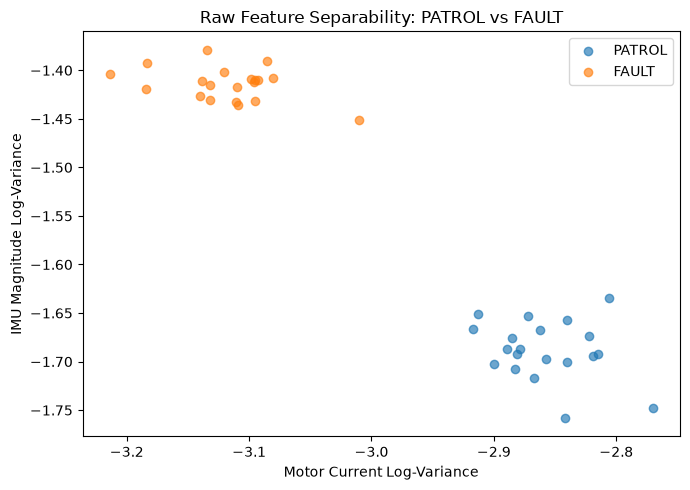

In [14]:
motor_idx = CHANNELS.index("motor_current")
imu_idx = CHANNELS.index("imu_magnitude")

plt.figure(figsize=(7, 5))

for cls in [CLASS_A, CLASS_B]:
    mask = y == cls

    plt.scatter(
        X_raw[mask, motor_idx],
        X_raw[mask, imu_idx],
        alpha=0.65,
        label=cls
    )

plt.xlabel("Motor Current Log-Variance")
plt.ylabel("IMU Magnitude Log-Variance")
plt.title("Raw Feature Separability: PATROL vs FAULT")
plt.legend()
plt.tight_layout()
plt.show()

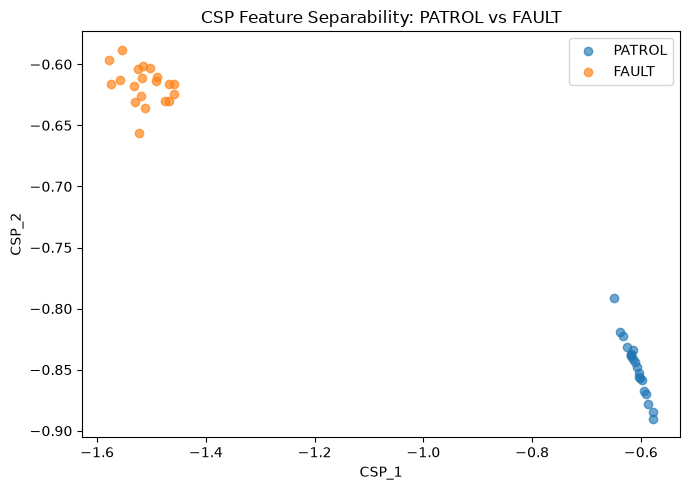

In [15]:
plt.figure(figsize=(7, 5))

for cls in [CLASS_A, CLASS_B]:
    mask = y == cls

    plt.scatter(
        X_csp[mask, 0],
        X_csp[mask, 1],
        alpha=0.65,
        label=cls
    )

plt.xlabel(filter_names[0])
plt.ylabel(filter_names[1])
plt.title("CSP Feature Separability: PATROL vs FAULT")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Quick class-separation summary

This is only a descriptive check. Formal classification performance will be evaluated in `W03_LDA_Classifier.ipynb`.


In [16]:
csp_df = pd.DataFrame(X_csp, columns=filter_names)
csp_df["label"] = y

raw_df = pd.DataFrame(X_raw, columns=raw_feature_names)
raw_df["label"] = y

print("Mean CSP features by class:")
display(csp_df.groupby("label").mean())

print("Mean raw log-variance features by class:")
display(raw_df.groupby("label").mean())


Mean CSP features by class:


,CSP_1,CSP_2,CSP_3,CSP_4
label,,,,
FAULT,-1.512473,-0.617010,-1.440369,-5.858604
PATROL,-0.609054,-0.847912,-3.598409,-8.480036


Mean raw log-variance features by class:


,logvar_motor_current,logvar_accel_x,logvar_accel_y,logvar_accel_z,logvar_imu_magnitude
label,,,,,
FAULT,-3.118084,-1.456134,-1.444843,-1.412704,-1.414362
PATROL,-2.857997,-1.200579,-1.304237,-1.688343,-1.687964


## 14. Interpretation

The CSP transformation produced a more discriminative representation of the
PATROL and FAULT sensor windows than the original channel-level log-variance
features. In the raw feature space, differences between the two operating
modes are distributed across individual sensor channels, so the separation is
less directly expressed in a small number of dimensions. After CSP, the class
differences become concentrated into a smaller set of components.

The generalized eigenvalues ranged from approximately **4.02 to 0.12**,
indicating that the two operating modes have substantially different variance
along some projected sensor directions. CSP_1 corresponds to the largest
generalized eigenvalue and therefore emphasizes a direction with relatively
greater variance for PATROL, while the components associated with the smallest
eigenvalues emphasize directions with relatively greater variance for FAULT.

The learned spatial filters also show that CSP does not rely on a single sensor.
For example, CSP_1 is dominated by **motor current**, with additional
contributions from the acceleration channels, while the filters at the opposite
end of the eigenvalue spectrum place stronger weights on **accel_z** and
**IMU magnitude**. This suggests that the distinction between PATROL and FAULT
is represented not only by changes in individual sensor signals, but also by
changes in the covariance structure across multiple sensor channels.

Overall, the result supports the transfer of the CSP idea from EEG to robot
telemetry. In EEG, CSP finds combinations of electrode channels whose variance
best distinguishes two neural conditions. Here, the same mathematical
principle finds combinations of robot sensor channels whose variance
distinguishes two operational modes. The physical interpretation of a
"channel" changes, but the covariance-based feature extraction principle
remains the same.

These CSP features will next be evaluated quantitatively using LDA and compared
against majority-class and raw-feature logistic-regression baselines.